In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip install -q datasets PyYAML

In [3]:
from pathlib import Path

import torch


PROJECT_ROOT = Path(
    "/content/drive/MyDrive/ATML/PA1"
)

REPO_ROOT = Path(
    "/content/drive/MyDrive/ATML/PA1-repo"
)

TASK3_WORK_ROOT = (
    PROJECT_ROOT / "task3"
)

TASK3_REPO_ROOT = (
    REPO_ROOT / "task3"
)

PACS_ROOT = (
    PROJECT_ROOT / "datasets/PACS"
)

SOURCE_SPLIT_PATH = (
    REPO_ROOT
    / "shared/splits/"
    "pacs_sketch_seed6304.json"
)

CHECKPOINT_PATH = (
    TASK3_WORK_ROOT
    / "checkpoints/sam_best.pt"
)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

if DEVICE.type != "cuda":
    raise RuntimeError(
        "Change the Colab runtime to GPU."
    )

print(
    "GPU:",
    torch.cuda.get_device_name(0),
)

Device: cuda
GPU: Tesla T4


In [4]:
%cd /content/drive/MyDrive/ATML/PA1-repo

import json

import yaml

import matplotlib.pyplot as plt

import pandas as pd

import torch

from datasets import load_from_disk

from common.seed import set_seed

from shared.pacs_protocol import (
    load_pacs_protocol,
)

from task2.evaluation.source_validation import (
    evaluate_source_domains,
)

from task2.models.backbone import (
    count_trainable_parameters,
)

from task2.models.classifier_head import (
    PACSClassifier,
)

from task2.selection.checkpointing import (
    SourceValidationSelector,
)

from task3.data.source_loaders import (
    build_task3_source_datasets,
    build_task3_source_loaders,
)

from task3.methods.sam import (
    SAMOptimizer,
)

from task3.train import (
    train_task3_method,
)


SEED = 6304

set_seed(SEED)

with (
    TASK3_REPO_ROOT
    / "configs/base.yaml"
).open(
    "r",
    encoding="utf-8",
) as config_file:
    base_config = yaml.safe_load(
        config_file
    )

with (
    TASK3_REPO_ROOT
    / "configs/sam.yaml"
).open(
    "r",
    encoding="utf-8",
) as config_file:
    method_config = yaml.safe_load(
        config_file
    )

print(
    "Method:",
    method_config["method"]["name"],
)

print(
    "SAM radius:",
    method_config["method"]["rho"],
)

print(
    "Adaptive SAM:",
    method_config["method"][
        "adaptive"
    ],
)

print(
    "Target images allowed:",
    base_config["selection"][
        "use_target_images"
    ],
)

/content/drive/.shortcut-targets-by-id/1tphHcVs5KfBbfa3Y2U6Gt0Lo7AWXysa4/ATML/PA1-repo
Method: sam
SAM radius: 0.05
Adaptive SAM: False
Target images allowed: False


In [5]:
pacs_dataset = load_from_disk(
    str(PACS_ROOT)
)

pacs_protocol = load_pacs_protocol(
    SOURCE_SPLIT_PATH
)

source_datasets = (
    build_task3_source_datasets(
        dataset=pacs_dataset,
        protocol=pacs_protocol,
    )
)

print(
    "Dataset groups:",
    list(source_datasets.keys()),
)

print(
    "Training domains:",
    list(
        source_datasets[
            "source_train"
        ].keys()
    ),
)

print(
    "Target dataset created:",
    any(
        "target" in key.lower()
        for key in (
            source_datasets.keys()
        )
    ),
)

Dataset groups: ['source_train', 'source_validation']
Training domains: ['photo', 'art_painting', 'cartoon']
Target dataset created: False


In [6]:
source_loaders = (
    build_task3_source_loaders(
        datasets=source_datasets,
        source_batch_size=(
            base_config["batching"][
                "examples_per_source_domain"
            ]
        ),
        evaluation_batch_size=(
            base_config["batching"][
                "evaluation_batch_size"
            ]
        ),
        number_of_workers=(
            base_config["batching"][
                "number_of_workers"
            ]
        ),
        seed=SEED,
    )
)

print(
    "Steps per epoch:",
    source_loaders[
        "steps_per_epoch"
    ],
)

print(
    "Total source batch size:",
    (
        base_config["batching"][
            "examples_per_source_domain"
        ]
        * len(
            source_loaders[
                "source_train"
            ]
        )
    ),
)

Steps per epoch: 234
Total source batch size: 24


In [7]:
set_seed(SEED)

model = PACSClassifier(
    number_of_classes=7
).to(DEVICE)

base_optimizer = (
    torch.optim.AdamW(
        model.parameters(),
        lr=(
            base_config[
                "optimization"
            ]["learning_rate"]
        ),
        weight_decay=(
            base_config[
                "optimization"
            ]["weight_decay"]
        ),
    )
)

optimizer = SAMOptimizer(
    base_optimizer=base_optimizer,
    rho=(
        method_config["method"][
            "rho"
        ]
    ),
    adaptive=(
        method_config["method"][
            "adaptive"
        ]
    ),
)

selector = SourceValidationSelector(
    checkpoint_path=CHECKPOINT_PATH,
    patience=(
        base_config["optimization"][
            "early_stopping_patience"
        ]
    ),
)

print(
    "Trainable parameters:",
    count_trainable_parameters(
        model
    ),
)

print(
    "SAM radius:",
    optimizer.rho,
)

print(
    "Checkpoint:",
    CHECKPOINT_PATH,
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 158MB/s]


Trainable parameters: 11180103
SAM radius: 0.05
Checkpoint: /content/drive/MyDrive/ATML/PA1/task3/checkpoints/sam_best.pt


In [8]:
training_result = (
    train_task3_method(
        method_name="sam",
        model=model,
        loaders=source_loaders,
        optimizer=optimizer,
        selector=selector,
        device=DEVICE,
        maximum_epochs=(
            base_config[
                "optimization"
            ]["maximum_epochs"]
        ),
        gradient_clip_norm=(
            base_config[
                "optimization"
            ]["gradient_clip_norm"]
        ),
        number_of_classes=7,
    )
)

model = training_result["model"]

training_history = (
    training_result["history"]
)

selected_checkpoint = (
    training_result[
        "selected_checkpoint"
    ]
)

history_path = (
    TASK3_REPO_ROOT
    / "results/"
    "sam_training_history.csv"
)

training_history.to_csv(
    history_path,
    index=False,
)

print()
print(
    "Selected epoch:",
    selected_checkpoint["epoch"],
)

print(
    "Selected mean source macro-F1:",
    selected_checkpoint[
        "selection_score"
    ],
)

print(
    "History saved to:",
    history_path,
)

sam epoch 1:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 1: train loss=1.0690, mean validation macro-F1=0.8854, best=0.8854


sam epoch 2:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 2: train loss=0.4995, mean validation macro-F1=0.9093, best=0.9093


sam epoch 3:   0%|          | 0/234 [00:00<?, ?it/s]

...

Epoch 14: train loss=0.1063, mean validation macro-F1=0.9455, best=0.9515


sam epoch 15:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 15: train loss=0.0986, mean validation macro-F1=0.9449, best=0.9515


sam epoch 16:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 16: train loss=0.0906, mean validation macro-F1=0.9435, best=0.9515
Early stopping triggered.

Selected epoch: 11
Selected mean source macro-F1: 0.9515140737316559
History saved to: /content/drive/MyDrive/ATML/PA1-repo/task3/results/sam_training_history.csv


In [9]:
source_validation_results = (
    evaluate_source_domains(
        model=model,
        validation_loaders=(
            source_loaders[
                "source_validation"
            ]
        ),
        device=DEVICE,
        number_of_classes=7,
    )
)

source_result_rows = []

for domain_name, metrics in (
    source_validation_results[
        "domains"
    ].items()
):
    source_result_rows.append(
        {
            "method": "sam",
            "domain": domain_name,
            "accuracy": (
                metrics["accuracy"]
            ),
            "macro_f1": (
                metrics["macro_f1"]
            ),
            "loss": metrics["loss"],
            "number_of_samples": (
                metrics[
                    "number_of_samples"
                ]
            ),
        }
    )

source_result_table = pd.DataFrame(
    source_result_rows
)

source_result_path = (
    TASK3_REPO_ROOT
    / "results/"
    "sam_source_validation.csv"
)

source_result_table.to_csv(
    source_result_path,
    index=False,
)

print(
    source_result_table.to_string(
        index=False
    )
)

print()
print(
    "Mean source accuracy:",
    source_validation_results[
        "aggregate"
    ]["mean_accuracy"],
)

print(
    "Mean source macro-F1:",
    source_validation_results[
        "aggregate"
    ]["mean_macro_f1"],
)

print(
    "Worst source accuracy:",
    source_validation_results[
        "aggregate"
    ]["worst_accuracy"],
)

print(
    "Worst source macro-F1:",
    source_validation_results[
        "aggregate"
    ]["worst_macro_f1"],
)

method       domain  accuracy  macro_f1     loss  number_of_samples
   sam        photo  0.967066  0.962268 0.102464                334
   sam art_painting  0.921951  0.923944 0.226950                410
   sam      cartoon  0.963753  0.968330 0.117388                469

Mean source accuracy: 0.950923251006957
Mean source macro-F1: 0.9515140737316559
Worst source accuracy: 0.9219512195121952
Worst source macro-F1: 0.9239444762879704


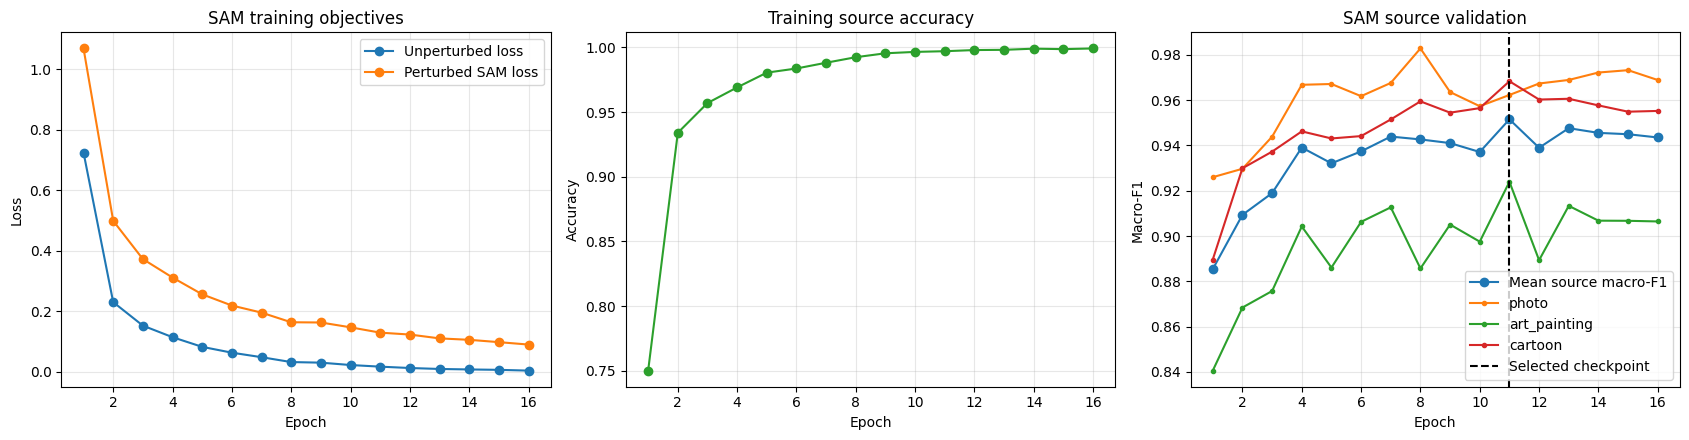

Figure saved to: /content/drive/MyDrive/ATML/PA1-repo/task3/figures/sam_training_curves.png


In [10]:
figure, axes = plt.subplots(
    1,
    3,
    figsize=(17, 4.5),
)

axes[0].plot(
    training_history["epoch"],
    training_history[
        "training_unperturbed_loss"
    ],
    marker="o",
    label="Unperturbed loss",
)

axes[0].plot(
    training_history["epoch"],
    training_history[
        "training_total_loss"
    ],
    marker="o",
    label="Perturbed SAM loss",
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("SAM training objectives")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    training_history["epoch"],
    training_history[
        "training_source_accuracy"
    ],
    marker="o",
    color="tab:green",
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training source accuracy")
axes[1].grid(alpha=0.3)

axes[2].plot(
    training_history["epoch"],
    training_history[
        "mean_source_validation_macro_f1"
    ],
    marker="o",
    label="Mean source macro-F1",
)

for domain_name in [
    "photo",
    "art_painting",
    "cartoon",
]:
    axes[2].plot(
        training_history["epoch"],
        training_history[
            f"{domain_name}_validation_macro_f1"
        ],
        marker=".",
        label=domain_name,
    )

axes[2].axvline(
    selected_checkpoint["epoch"],
    color="black",
    linestyle="--",
    label="Selected checkpoint",
)

axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Macro-F1")
axes[2].set_title("SAM source validation")
axes[2].grid(alpha=0.3)
axes[2].legend()

figure.tight_layout()

figure_path = (
    TASK3_REPO_ROOT
    / "figures/sam_training_curves.png"
)

figure_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

figure.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to:",
    figure_path,
)

In [11]:
sam_metadata = {
    "method": "sam",
    "seed": SEED,
    "rho": float(
        method_config[
            "method"
        ]["rho"]
    ),
    "adaptive": bool(
        method_config[
            "method"
        ]["adaptive"]
    ),
    "base_optimizer": "AdamW",
    "learning_rate": float(
        base_config[
            "optimization"
        ]["learning_rate"]
    ),
    "weight_decay": float(
        base_config[
            "optimization"
        ]["weight_decay"]
    ),
    "gradient_clip_norm": float(
        base_config[
            "optimization"
        ]["gradient_clip_norm"]
    ),
    "selected_epoch": int(
        selected_checkpoint["epoch"]
    ),
    "selection_metric": (
        selected_checkpoint[
            "selection_metric"
        ]
    ),
    "selection_score": float(
        selected_checkpoint[
            "selection_score"
        ]
    ),
    "checkpoint_filename": (
        CHECKPOINT_PATH.name
    ),
    "target_images_loaded": False,
    "target_labels_used": False,
    "source_validation": {
        domain_name: {
            "accuracy": float(
                metrics["accuracy"]
            ),
            "macro_f1": float(
                metrics["macro_f1"]
            ),
            "loss": float(
                metrics["loss"]
            ),
            "number_of_samples": int(
                metrics[
                    "number_of_samples"
                ]
            ),
        }
        for domain_name, metrics
        in source_validation_results[
            "domains"
        ].items()
    },
    "aggregate_source_validation": {
        key: float(value)
        for key, value
        in source_validation_results[
            "aggregate"
        ].items()
    },
}

metadata_path = (
    TASK3_REPO_ROOT
    / "results/sam_metadata.json"
)

with metadata_path.open(
    "w",
    encoding="utf-8",
) as metadata_file:
    json.dump(
        sam_metadata,
        metadata_file,
        indent=2,
    )

print(
    json.dumps(
        sam_metadata,
        indent=2,
    )
)

{
  "method": "sam",
  "seed": 6304,
  "rho": 0.05,
  "adaptive": false,
  "base_optimizer": "AdamW",
  "learning_rate": 0.0001,
  "weight_decay": 0.0001,
  "gradient_clip_norm": 1.0,
  "selected_epoch": 11,
  "selection_metric": "mean_source_validation_macro_f1",
  "selection_score": 0.9515140737316559,
  "checkpoint_filename": "sam_best.pt",
  "target_images_loaded": false,
  "target_labels_used": false,
  "source_validation": {
    "photo": {
      "accuracy": 0.9670658682634731,
      "macro_f1": 0.9622677065220303,
      "loss": 0.10246352021565694,
      "number_of_samples": 334
    },
    "art_painting": {
      "accuracy": 0.9219512195121952,
      "macro_f1": 0.9239444762879704,
      "loss": 0.2269501229611839,
      "number_of_samples": 410
    },
    "cartoon": {
      "accuracy": 0.9637526652452025,
      "macro_f1": 0.968330038384967,
      "loss": 0.11738831935915103,
      "number_of_samples": 469
    }
  },
  "aggregate_source_validation": {
    "mean_accuracy": 0.9509